In [1]:
!date

Thu Sep 17 23:51:31 PDT 2026


In [2]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

projdir = '/u/project/cluo/terencew/claude/project_ideas/asm_lr_hprc2'
outdir = f'{projdir}/results/qc/data/qc17'
figdir = f'{projdir}/figures/qc'

In [3]:
### global mCG straight from the modbeds (call-weighted, every read) -- all 229 donors, not just the 201 with PMD calls
g = pd.read_csv(f'{projdir}/results/qc/data/global_methylation_covariates_full_cohort.tsv', sep='\t')
g = g.groupby('sample_id').frac_meth.mean().rename('global_mcg_modbed').reset_index().rename(columns={'sample_id': 'sample'})
g.head()

,sample,global_mcg_modbed
0,HG00097,0.628658
1,HG00099,0.668343
2,HG00126,0.660217
3,HG00128,0.637756
4,HG00133,0.659980


In [4]:
g.shape

(219, 2)

In [5]:
### per-donor PMD phenotypes + covariates (qc13 table, 201 donors)
m = pd.read_csv(f'{projdir}/results/qc/data/qc13/donor_pmd_expansion_metrics.tsv', sep='\t')
m.head()

,sample,mcg_never,mcg_constitutive,mcg_variable,mcg_rare,depth_constitutive,depth_variable,depth_rare,breadth_lt0.5,breadth_lt0.6,...,hprc2_meth_qc_flag,global_meth,mean_depth,pmd_burden_bp,frac_cpg_in_pmd,map_rate,population,id_prefix,collection,boundary_spread
0,HG00097,0.778194,0.532610,0.603890,0.648395,0.245584,0.174304,0.129798,0.196346,0.467882,...,0,0.520791,25.406927,1.550922e+09,0.403401,0.821983,GBR,HG,1000G,-0.051597
1,HG00099,0.789830,0.591849,0.659184,0.688841,0.197980,0.130646,0.100989,0.090726,0.302461,...,0,0.518563,27.449030,1.322907e+09,0.335799,0.817794,GBR,HG,1000G,NaN
2,HG00126,0.782072,0.593786,0.653631,0.682833,0.188286,0.128441,0.099239,0.087115,0.304393,...,0,0.529499,33.732242,1.347435e+09,0.358318,0.835642,GBR,HG,1000G,NaN
3,HG00128,0.788791,0.552431,0.626630,0.666893,0.236361,0.162161,0.121899,0.153676,0.413779,...,0,0.522023,26.792516,1.611503e+09,0.444308,0.821778,GBR,HG,1000G,NaN
4,HG00133,0.787096,0.585918,0.652731,0.686317,0.201178,0.134365,0.100780,0.096075,0.321514,...,0,0.528512,31.055373,1.391396e+09,0.356709,0.833830,GBR,HG,1000G,NaN


In [6]:
m.shape

(201, 29)

In [7]:
### covariates for all 229: chemistry from HPRC2 S6, sex from the 1000G ped, passage from HPRC2 S15
seq = pd.read_csv(f'{projdir}/results/qc/data/supp_seq_qc.csv').rename(columns={'sample_id': 'sample', 'sequencing_chemistry_ont': 'chemistry'})
ped = pd.read_csv(f'{projdir}/results/qc/data/g1k_3202_samples_ped_population.txt', sep=' ')[['SampleID', 'Sex']]
ped = ped.rename(columns={'SampleID': 'sample'}).assign(sex=lambda x: x.Sex.map({1: 'male', 2: 'female'}))[['sample', 'sex']]
s15 = pd.read_excel(f'{projdir}/reference/hprc2/hprc2_supp.xlsx', sheet_name='S15', header=1)
s15 = s15[['Cell Line Sample ID', 'Cell Line Passage*']].rename(columns={'Cell Line Sample ID': 'sample', 'Cell Line Passage*': 'passage'})
man = pd.read_csv(f'{projdir}/tsv/meta/hprc2_sample_manifest.tsv', sep='\t')[['sample_id', 'superpopulation']].rename(columns={'sample_id': 'sample'})
cov = man.merge(seq[['sample', 'chemistry', 'read_N50_ont', 'coverage_ont']], on='sample', how='left').merge(ped, on='sample', how='left').merge(s15, on='sample', how='left')
cov.head()

,sample,superpopulation,chemistry,read_N50_ont,coverage_ont,sex,passage
0,HG00097,EUR,R1041,89210.35,57.09,female,5.0
1,HG00099,EUR,R941,72139.93,58.78,female,5.0
2,HG00126,EUR,R1041,107245.82,70.94,male,5.0
3,HG00128,EUR,R1041,92413.37,59.52,female,5.0
4,HG00133,EUR,R1041,105700.81,65.96,female,5.0


In [8]:
cov.shape

(229, 7)

In [9]:
### extra donor-state covariates: XIST promoter skew (females), EBV transcription (Kinnex, per ACTB)
xist = pd.read_csv(f'{projdir}/results/qc/data/xist_promoter_skew.tsv', sep='\t')[['sample', 'skew']].rename(columns={'skew': 'xist_skew'})
rna = pd.read_csv(f'{projdir}/results/qc/data/rna_markers_wide.tsv', sep='\t')
rna['log_ebv'] = np.log10((rna.EBV_plus + rna.EBV_minus + 1) / rna.ACTB)
extra = m[['sample', 'established', 'id_prefix', 'hprc2_meth_qc_flag', 'mean_depth']].merge(xist, on='sample', how='left').merge(rna[['sample', 'log_ebv']], on='sample', how='left')
extra.head()

,sample,established,id_prefix,hprc2_meth_qc_flag,mean_depth,xist_skew,log_ebv
0,HG00097,External,HG,0,25.406927,0.471476,-1.310384
1,HG00099,External,HG,0,27.449030,0.781786,-0.808554
2,HG00126,External,HG,0,33.732242,NaN,-1.661712
3,HG00128,External,HG,0,26.792516,0.455455,-1.570553
4,HG00133,External,HG,0,31.055373,0.273500,-1.385520


In [10]:
metrics = ['global_mcg_modbed', 'global_meth', 'depth_constitutive', 'mcg_never', 'mcg_constitutive', 'own_pmd_bin_frac', 'pmd_burden_bp']
d = cov.merge(g, on='sample', how='left').merge(m[['sample'] + metrics[1:]], on='sample', how='left').merge(extra, on='sample', how='left')
d['pmd_burden_bp'] = d.pmd_burden_bp / 1e9
d = d[d.chemistry.notna()]
d.head()

,sample,superpopulation,chemistry,read_N50_ont,coverage_ont,sex,passage,global_mcg_modbed,global_meth,depth_constitutive,mcg_never,mcg_constitutive,own_pmd_bin_frac,pmd_burden_bp,established,id_prefix,hprc2_meth_qc_flag,mean_depth,xist_skew,log_ebv
0,HG00097,EUR,R1041,89210.35,57.09,female,5.0,0.628658,0.520791,0.245584,0.778194,0.532610,0.494646,1.550922,External,HG,0.0,25.406927,0.471476,-1.310384
1,HG00099,EUR,R941,72139.93,58.78,female,5.0,0.668343,0.518563,0.197980,0.789830,0.591849,0.426773,1.322907,External,HG,0.0,27.449030,0.781786,-0.808554
2,HG00126,EUR,R1041,107245.82,70.94,male,5.0,0.660217,0.529499,0.188286,0.782072,0.593786,0.441540,1.347435,External,HG,0.0,33.732242,NaN,-1.661712
3,HG00128,EUR,R1041,92413.37,59.52,female,5.0,0.637756,0.522023,0.236361,0.788791,0.552431,0.508949,1.611503,External,HG,0.0,26.792516,0.455455,-1.570553
4,HG00133,EUR,R1041,105700.81,65.96,female,5.0,0.659980,0.528512,0.201178,0.787096,0.585918,0.446916,1.391396,External,HG,0.0,31.055373,0.273500,-1.385520


In [11]:
d.shape

(229, 20)

In [12]:
d[metrics].notna().sum()

global_mcg_modbed     219
global_meth           201
depth_constitutive    201
mcg_never             201
mcg_constitutive      201
own_pmd_bin_frac      201
pmd_burden_bp         201
dtype: int64

In [13]:
### marginal and chemistry-partial R2 for every metric x covariate
covariates = ['chemistry', 'superpopulation', 'sex', 'passage', 'established', 'id_prefix', 'hprc2_meth_qc_flag', 'xist_skew', 'log_ebv', 'read_N50_ont', 'mean_depth']
categorical = {'chemistry', 'superpopulation', 'sex', 'established', 'id_prefix', 'hprc2_meth_qc_flag'}
rows = []
for y in metrics:
    for c in covariates:
        sub = d[list(dict.fromkeys([y, c, 'chemistry']))].dropna()
        term = f'C({c})' if c in categorical else c
        if sub[c].nunique() < 2:
            continue
        full = smf.ols(f'{y} ~ {term}', sub).fit()
        r = {'metric': y, 'covariate': c, 'n': len(sub), 'r2': full.rsquared, 'p': full.f_pvalue}
        if c != 'chemistry':
            base = smf.ols(f'{y} ~ C(chemistry)', sub).fit()
            both = smf.ols(f'{y} ~ C(chemistry) + {term}', sub).fit()
            r['partial_r2_given_chem'] = (base.ssr - both.ssr) / base.ssr
            r['p_given_chem'] = both.compare_f_test(base)[1]
        rows.append(r)
assoc = pd.DataFrame(rows)
assoc.head()

,metric,covariate,n,r2,p,partial_r2_given_chem,p_given_chem
0,global_mcg_modbed,chemistry,219,0.188662,1.720257e-11,NaN,NaN
1,global_mcg_modbed,superpopulation,211,0.115713,4.076789e-05,0.051475,0.027874
2,global_mcg_modbed,sex,211,0.016748,6.057587e-02,0.010423,0.140354
3,global_mcg_modbed,passage,157,0.038394,1.391592e-02,0.000308,0.827938
4,global_mcg_modbed,established,155,0.107281,3.180322e-05,0.002822,0.512906


In [14]:
assoc.shape

(70, 7)

In [15]:
### same, R9.4.1 donors only (no chemistry term needed) -- the replication RESULTS §1 asks for
rows = []
r9 = d[d.chemistry == 'R941']
for y in metrics:
    for c in covariates[1:]:
        sub = r9[[y, c]].dropna()
        if sub[c].nunique() < 2:
            continue
        term = f'C({c})' if c in categorical else c
        f = smf.ols(f'{y} ~ {term}', sub).fit()
        rows.append({'metric': y, 'covariate': c, 'n': len(sub), 'r2_r941': f.rsquared, 'p_r941': f.f_pvalue})
assoc_r9 = pd.DataFrame(rows)
assoc = assoc.merge(assoc_r9, on=['metric', 'covariate'], how='left', suffixes=('', '_r941'))
assoc.sort_values('p').head(20)

,metric,covariate,n,r2,p,partial_r2_given_chem,p_given_chem,n_r941,r2_r941,p_r941
15,global_meth,hprc2_meth_qc_flag,201,0.294195,9.052365e-17,0.286845,3.049277e-16,146.0,0.006208,3.445013e-01
25,depth_constitutive,hprc2_meth_qc_flag,201,0.216484,3.424039e-12,0.218348,3.050465e-12,146.0,0.131796,6.684162e-06
45,mcg_constitutive,hprc2_meth_qc_flag,201,0.215687,3.795109e-12,0.217837,3.258100e-12,146.0,0.135329,4.923745e-06
0,global_mcg_modbed,chemistry,219,0.188662,1.720257e-11,NaN,NaN,NaN,NaN,NaN
40,mcg_constitutive,chemistry,201,0.193404,6.492543e-11,NaN,NaN,NaN,NaN,NaN
20,depth_constitutive,chemistry,201,0.190667,9.156692e-11,NaN,NaN,NaN,NaN,NaN
35,mcg_never,hprc2_meth_qc_flag,201,0.167325,1.649364e-09,0.160894,3.953384e-09,146.0,0.103390,7.575803e-05
30,mcg_never,chemistry,201,0.157668,5.343467e-09,NaN,NaN,NaN,NaN,NaN
55,own_pmd_bin_frac,hprc2_meth_qc_flag,201,0.123910,2.984664e-07,0.122694,3.683335e-07,146.0,0.090887,2.174391e-04
65,pmd_burden_bp,hprc2_meth_qc_flag,201,0.117242,6.511762e-07,0.111402,1.366399e-06,146.0,0.091558,2.055234e-04


In [16]:
### joint model per metric on complete cases: type-II sums of squares -> share of variance per covariate
joint_terms = ['C(chemistry)', 'C(superpopulation)', 'C(sex)', 'passage', 'C(established)', 'C(hprc2_meth_qc_flag)']
rows = []
for y in metrics:
    sub = d[[y, 'chemistry', 'superpopulation', 'sex', 'passage', 'established', 'hprc2_meth_qc_flag']].dropna()
    f = smf.ols(f'{y} ~ ' + ' + '.join(joint_terms), sub).fit()
    a = sm.stats.anova_lm(f, typ=2)
    tot = ((sub[y] - sub[y].mean()) ** 2).sum()
    for t in a.index:
        rows.append({'metric': y, 'term': t, 'n': len(sub), 'frac_ss': a.loc[t, 'sum_sq'] / tot, 'p': a.loc[t, 'PR(>F)']})
    rows.append({'metric': y, 'term': 'model_r2', 'n': len(sub), 'frac_ss': f.rsquared, 'p': f.f_pvalue})
joint = pd.DataFrame(rows)
joint.pivot(index='term', columns='metric', values='frac_ss').round(3)

metric,depth_constitutive,global_mcg_modbed,global_meth,mcg_constitutive,mcg_never,own_pmd_bin_frac,pmd_burden_bp
term,,,,,,,
C(chemistry),0.062,0.088,0.002,0.070,0.067,0.001,0.003
C(established),0.002,0.002,0.028,0.001,0.000,0.000,0.001
C(hprc2_meth_qc_flag),0.034,0.021,0.006,0.023,0.002,0.019,0.019
C(sex),0.002,0.004,0.234,0.001,0.000,0.002,0.041
C(superpopulation),0.021,0.013,0.082,0.015,0.014,0.028,0.025
Residual,0.725,0.704,0.583,0.744,0.833,0.941,0.876
model_r2,0.275,0.296,0.417,0.256,0.167,0.059,0.124
passage,0.000,0.000,0.000,0.001,0.001,0.000,0.001


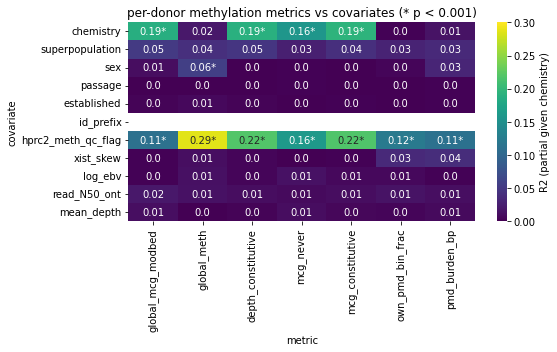

In [17]:
### heatmap: chemistry-partial R2 (chemistry row = marginal R2)
h = assoc.assign(val=lambda x: x.partial_r2_given_chem.fillna(x.r2)).pivot(index='covariate', columns='metric', values='val').reindex(index=covariates, columns=metrics)
star = assoc.assign(pp=lambda x: x.p_given_chem.fillna(x.p)).pivot(index='covariate', columns='metric', values='pp').reindex(index=covariates, columns=metrics)
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(h, annot=h.round(2).astype(str) + np.where(star < 0.001, '*', ''), fmt='', cmap='viridis', vmin=0, vmax=0.3, ax=ax, cbar_kws={'label': 'R2 (partial given chemistry)'})
ax.set_title('per-donor methylation metrics vs covariates (* p < 0.001)')
plt.tight_layout()
plt.savefig(f'{figdir}/qc17_variance_explained_covariates.png', dpi=150)

In [18]:
### chemistry effect with and without the HPRC2 QC flag -- the flag is the strongest single covariate for depth
for y in ['global_mcg_modbed', 'depth_constitutive']:
    sub = d[[y, 'chemistry', 'hprc2_meth_qc_flag']].dropna()
    print(y, smf.ols(f'{y} ~ C(chemistry)', sub).fit().rsquared.round(3), smf.ols(f'{y} ~ C(chemistry) + C(hprc2_meth_qc_flag)', sub).fit().rsquared.round(3))

global_mcg_modbed 0.21 0.297
depth_constitutive 0.191 0.367


In [19]:
assoc.to_csv(f'{outdir}/metric_covariate_r2.tsv', sep='\t', index=False)
joint.to_csv(f'{outdir}/joint_model_variance_partition.tsv', sep='\t', index=False)
d.to_csv(f'{outdir}/donor_metrics_covariates.tsv', sep='\t', index=False)

In [20]:
!date

Thu Sep 17 23:51:53 PDT 2026
